In [22]:
import pandas as pd
import torch
from torchvision import transforms
from torchvision.transforms import ToPILImage
from matplotlib import pyplot as plt

from PIL import Image
from io import BytesIO

from IPython.display import display

In [23]:
df = pd.read_parquet("hf://datasets/flwrlabs/pacs/data/train-00000-of-00001.parquet")

In [24]:
labels = ['dog', 'elephant', 'giraffe', 'guitar', 'horse', 'house', 'person']

In [25]:
df['pil_image'] = df['image'].apply(
    lambda x: Image.open(BytesIO(x['bytes']))
)
base_transform = transforms.ToTensor()
df['torch_image'] = df['pil_image'].map(base_transform)

In [26]:
downsample_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor()
])
to_pil = ToPILImage()

df['torch_image_downsampled'] = df['pil_image'].map(downsample_transform)
df['pil_image_downsampled'] = df['torch_image_downsampled'].map(to_pil)

Visualize some photos and cartoons from the dataset

In [27]:
df_restrict = df[(df['domain'] == 'photo') | (df['domain'] == 'cartoon')]

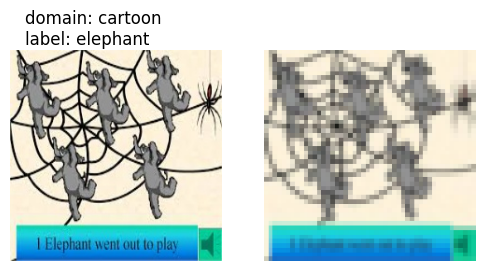

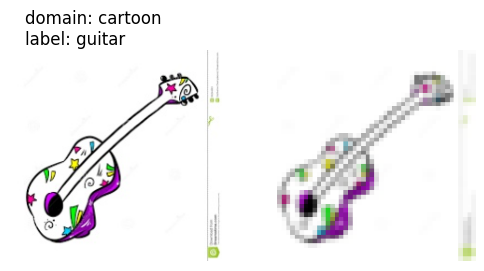

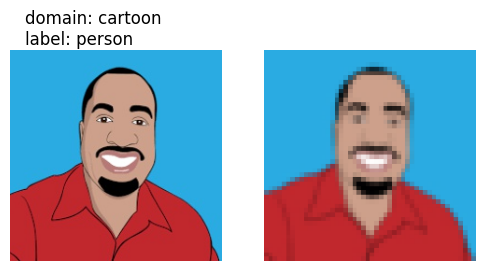

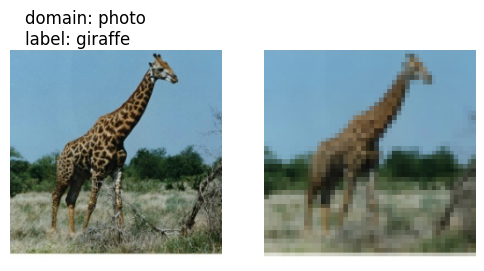

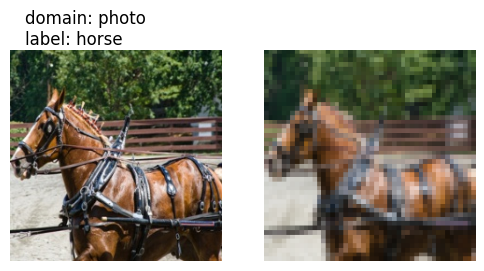

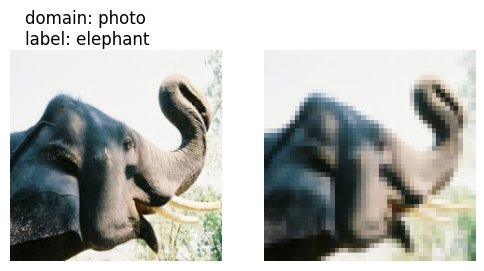

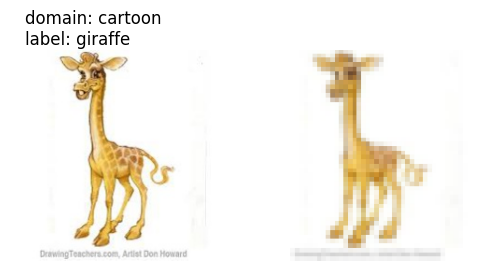

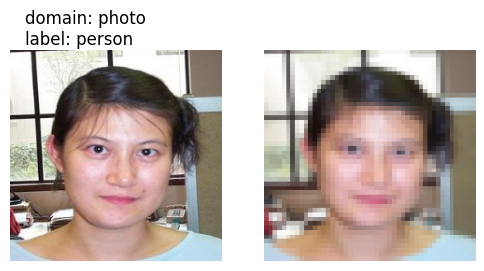

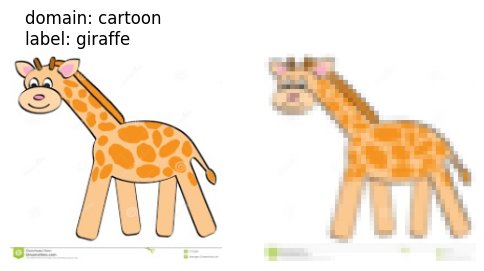

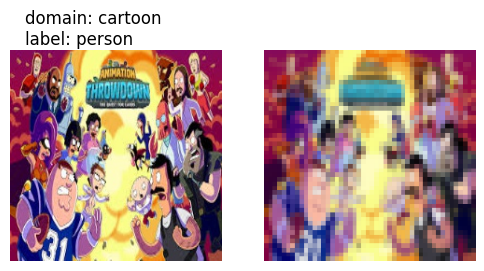

In [28]:
for _, row in df_restrict.sample(10).iterrows():
    fig, ax = plt.subplots(1, 2, figsize=(6, 3))

    title = f"domain: {row['domain']}\nlabel: {labels[row['label']]}"

    fig.suptitle(title, x=0.15, ha='left')

    ax[0].imshow(row['pil_image'])
    ax[0].axis('off')

    ax[1].imshow(
        row['pil_image_downsampled'].resize((227, 227), Image.NEAREST)
    )
    ax[1].axis('off')

    plt.show()

Train a LeNet model on the photos, and evaluate it on cartoons

In [29]:
from sklearn.model_selection import train_test_split

df_photo = df[df["domain"] == "photo"]
df_cartoon = df[df["domain"] == "cartoon"]

train_photo, test_photo = train_test_split(
    df_photo,
    test_size=0.2,
    random_state=42,
    stratify=df_photo["label"]
)

In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm, trange

In [31]:
# -------------------------
# Dataset wrapper
# -------------------------
class PACSDataset(Dataset):
    def __init__(self, df):
        self.images = df['torch_image_downsampled'].tolist()
        self.labels = df['label'].tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


# -------------------------
# LeNet
# -------------------------
class LeNet(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)

        self.fc1 = nn.Linear(16 * 9 * 9, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


# -------------------------
# Split domains
# -------------------------
df_photo = df[df["domain"] == "photo"]
df_cartoon = df[df["domain"] == "cartoon"]

In [32]:
train_loader = DataLoader(PACSDataset(train_photo), batch_size=32, shuffle=True)
test_photo_loader = DataLoader(PACSDataset(test_photo), batch_size=32)
test_cartoon_loader = DataLoader(PACSDataset(df_cartoon), batch_size=32)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = LeNet().to(device)

In [33]:
def evaluate(loader, name):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)

            correct += (pred == y).sum().item()
            total += y.size(0)

    print(f"{name}: {correct/total:.4f}")

Evaluate model before training

In [34]:
evaluate(test_photo_loader, "photo (in-domain test)")
evaluate(test_cartoon_loader, "cartoon (domain shift)")

photo (in-domain test): 0.1347
cartoon (domain shift): 0.1088


In [35]:
# -------------------------
# Train
# -------------------------
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
losses = []

for epoch in trange(20):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        opt.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        opt.step()

        total_loss += loss.item()
    
    losses.append(total_loss)

    # print(f"epoch {epoch}: loss={total_loss/len(train_loader):.4f}")

100%|██████████| 20/20 [00:01<00:00, 10.39it/s]


Evaluate model after training

In [36]:
evaluate(test_photo_loader, "photo (in-domain test)")
evaluate(test_cartoon_loader, "cartoon (domain shift)")

photo (in-domain test): 0.6078
cartoon (domain shift): 0.2594


Better than random on the cartoons!

In [37]:
from datasets import load_dataset
dst_all = load_dataset("flwrlabs/pacs", split="train")

In [38]:
dst_all.set_format(type="torch")

In [39]:
mean = torch.zeros(3)
sq_mean = torch.zeros(3)
num_pixels = 0

for example in tqdm(dst_all):
    image = example["image"].float()  # important

    mean += image.sum(dim=[1, 2])
    sq_mean += (image ** 2).sum(dim=[1, 2])

    num_pixels += image.shape[1] * image.shape[2]

mean /= num_pixels
std = (sq_mean / num_pixels - mean**2).sqrt()

print("mean:", mean)
print("std:", std)

100%|██████████| 9991/9991 [00:13<00:00, 744.45it/s]

mean: tensor([194.9427, 189.9413, 182.6311])
std: tensor([78.8681, 81.2360, 88.4603])


In [40]:
mean/256

tensor([0.7615, 0.7420, 0.7134])

In [41]:
std/256

tensor([0.3081, 0.3173, 0.3455])